In [2]:
import glob
import cv2
import numpy as np
import voxelmorph as vxm
import tf2onnx
import tensorflow as tf
import matplotlib.pyplot as plt

2025-05-22 20:26:58.120567: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-22 20:26:58.120617: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-22 20:26:58.120668: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
pairs = np.load("/home/j/FPGA-project/voxelmorph/data/ixi_pairs.npz")
moving = pairs["moving"]
fixed = pairs["fixed"]
zeros = pairs["zeros"]

print("Loaded pairs:", moving.shape)

Loaded pairs: (2000, 192, 224, 1)


In [ ]:
split = int(0.9 * len(moving))
x_train = (moving[:split], fixed[:split])
y_train = [fixed[:split], zeros[:split]]
x_val = (moving[split:], fixed[split:])
y_val = [fixed[split:], zeros[split:]]

print("Train pairs:", x_train[0].shape, "Val pairs:", x_val[0].shape)

Train pairs: (1800, 192, 224, 1) Val pairs: (200, 192, 224, 1)


In [5]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
vol_shape = moving.shape[1:-1] 
nb_features = [[32,32,32,32], [32,32,32,32,32,16]]
vxm_model = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)
losses = ['mse', vxm.losses.Grad('l2').loss]
wts = [1.0, 0.01]
vxm_model.compile('adam', loss=losses, loss_weights=wts)

In [ ]:
history = vxm_model.fit(
    x_train, y_train,
    batch_size=8,
    epochs=50,
    validation_data=(x_val, y_val)
)

Epoch 1/50
225/225 [==============================] - 14s 42ms/step - loss: 0.0196 - vxm_dense_transformer_loss: 0.0180 - vxm_dense_flow_loss: 0.1558 - val_loss: 0.0145 - val_vxm_dense_transformer_loss: 0.0124 - val_vxm_dense_flow_loss: 0.2063
Epoch 2/50
225/225 [==============================] - 9s 38ms/step - loss: 0.0141 - vxm_dense_transformer_loss: 0.0120 - vxm_dense_flow_loss: 0.2116 - val_loss: 0.0132 - val_vxm_dense_transformer_loss: 0.0108 - val_vxm_dense_flow_loss: 0.2398
Epoch 3/50
225/225 [==============================] - 8s 38ms/step - loss: 0.0130 - vxm_dense_transformer_loss: 0.0108 - vxm_dense_flow_loss: 0.2160 - val_loss: 0.0122 - val_vxm_dense_transformer_loss: 0.0100 - val_vxm_dense_flow_loss: 0.2204
Epoch 4/50
225/225 [==============================] - 8s 38ms/step - loss: 0.0125 - vxm_dense_transformer_loss: 0.0103 - vxm_dense_flow_loss: 0.2171 - val_loss: 0.0122 - val_vxm_dense_transformer_loss: 0.0098 - val_vxm_dense_flow_loss: 0.2400
Epoch 5/50
225/225 [=======

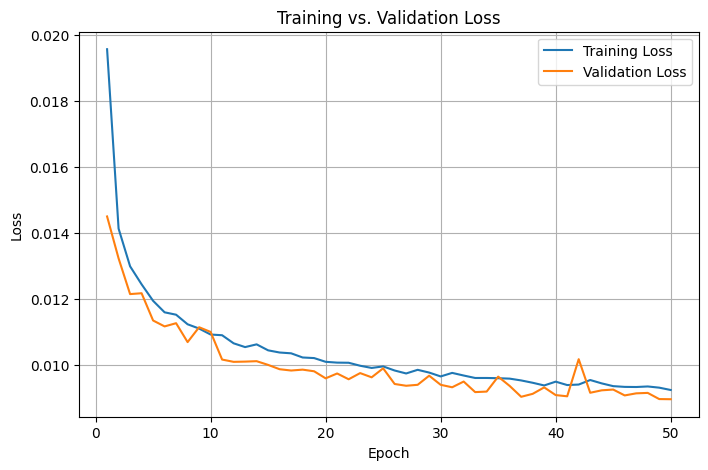

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
vxm_model.save('models/vxm2d_model_tf.h5')
vxm_model.save_weights('models/vxm2d_weights_tf.h5')

/home/j/miniconda3/envs/gen/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
spec = (
    tf.TensorSpec((None, *vol_shape, 1), tf.float32, name='moving'),
    tf.TensorSpec((None, *vol_shape, 1), tf.float32, name='fixed'),
)
tf2onnx.convert.from_keras(
    vxm_model, input_signature=spec,
    opset=13, output_path='models/vxm2d_model_tf.onnx'
)

(ir_version: 7
 producer_name: "tf2onnx"
 producer_version: "1.16.1 15c810"
 graph {
   node {
     input: "moving"
     output: "vxm_dense/vxm_dense_transformer/map/Shape:0"
     name: "vxm_dense/vxm_dense_transformer/map/Shape"
     op_type: "Shape"
   }
   node {
     input: "vxm_dense/vxm_dense_transformer/map/Shape:0"
     output: "vxm_dense/vxm_dense_transformer/map/Shape__73:0"
     name: "vxm_dense/vxm_dense_transformer/map/Shape__73"
     op_type: "Cast"
     attribute {
       name: "to"
       i: 6
       type: INT
     }
   }
   node {
     input: "moving"
     input: "fixed"
     output: "vxm_dense/vxm_dense_unet_input_concat/concat:0"
     name: "vxm_dense/vxm_dense_unet_input_concat/concat"
     op_type: "Concat"
     attribute {
       name: "axis"
       i: 3
       type: INT
     }
   }
   node {
     input: "vxm_dense/vxm_dense_unet_input_concat/concat:0"
     output: "vxm_dense/vxm_dense_unet_enc_conv_0_0/BiasAdd__79:0"
     name: "vxm_dense/vxm_dense_unet_enc_conv_

In [11]:
i = np.random.randint(x_val[0].shape[0])
mov_ex = x_val[0][i:i+1]
fix_ex = x_val[1][i:i+1]

warped, flow = vxm_model.predict([mov_ex, fix_ex])

1/1 [==============================] - 0s 465ms/step


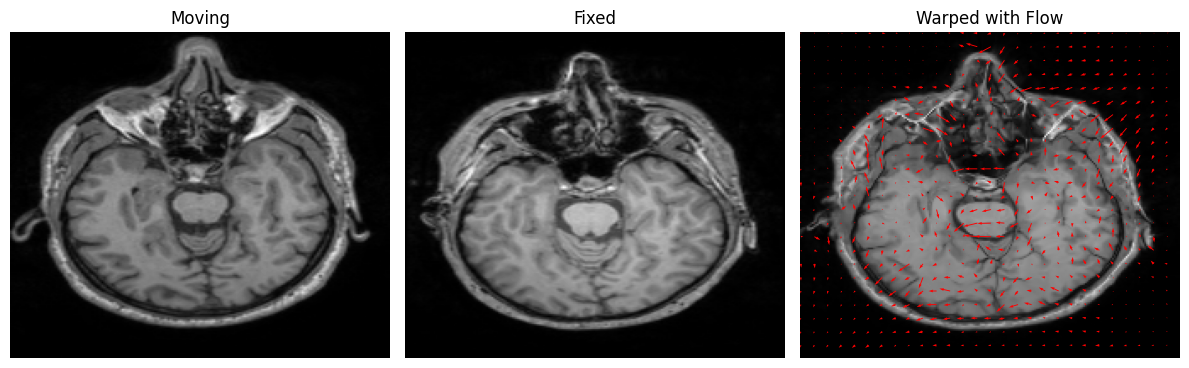

In [12]:
u = flow[0, :, :, 0]
v = flow[0, :, :, 1]

step = 8
h, w = u.shape
x = np.arange(0, w, step)
y = np.arange(0, h, step)
X, Y = np.meshgrid(x, y)
U = u[::step, ::step]
V = v[::step, ::step]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mov_ex[0, :, :, 0], cmap='gray')
plt.title("Moving")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(fix_ex[0, :, :, 0], cmap='gray')
plt.title("Fixed")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(warped[0, :, :, 0], cmap='gray')
plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color='r')
plt.title("Warped with Flow")
plt.axis('off')

plt.tight_layout()
plt.show()